# Grundlagen der Künstlichen Intelligenz.
# Exercise 10. Convolutional Neural Network (CNN)

**Autor:** Arturo Olivares Martos
***

- **Asignatura:** Grundlagen der Künstlichen Intelligenz.
- **Curso Académico:** 2025-26.
- **Grado:** Doble Grado en Ingeniería Informática y Matemáticas.
- **Grupo:** Erasmus.
- **Profesor:** Gérald Kämmerer
- **Descripción:** Práctica 10 de la asignatura GKI
<!--- **Fecha:** 17 de abril de 2023. -->
<!-- - **Duración:** -->

This exercise focuses on building and training a Convolutional Neural Network (CNN) using
PyTorch to classify images of chihuahuas and muffins. The dataset consists of images stored in
two separate folders: muffin and chihuahua (which were prepared in a former task). All images should have the same size (224, 224).

### Data Loading and Initial Inspection

Load the image data. You can use libraries like `torchvision.datasets.ImageFolder` to create datasets from the image directories. Specify the root directory containing the muffin and chihuahua folders.

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = './Aux/chihuahua-muffin/Filtered'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
image_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

Inspect the dataset. Determine the number of classes and the number of samples per class. You can access this information from the image dataset object.

In [2]:
print(f'Number of classes: {len(image_dataset.classes)}')
print(f'Total number of samples: {len(image_dataset)}')
print(f'Class to index mapping: {image_dataset.class_to_idx}')

# Show class distribution
class_counts = [0] * len(image_dataset.classes)
for _, label in image_dataset.samples:
    class_counts[label] += 1
for class_name, count in zip(image_dataset.classes, class_counts):
    print(f'\t- Class "{class_name}" has {count} samples.')


Number of classes: 2
Total number of samples: 1400
Class to index mapping: {'chihuahua': 0, 'muffin': 1}
	- Class "chihuahua" has 900 samples.
	- Class "muffin" has 500 samples.


### Data Preprocessing and Preparation

**Verify Image Sizes**: Although it is stated that all images have the same size (224, 224), write Python code to iterate through a few samples in your loaded image dataset and verify their dimensions. This is a good practice to ensure data consistency.

In [3]:
for i in range(5):  # Check the first 5 samples
    image, label = image_dataset[i]
    print(f'Sample {i+1}: Image size: {image.size()}, Label: {label}')

all_same_size = all(image.size() == (3, 224, 224) for image, _ in image_dataset)
if all_same_size:
    print("All images have the same size (3, 224, 224).")

Sample 1: Image size: torch.Size([3, 224, 224]), Label: 0
Sample 2: Image size: torch.Size([3, 224, 224]), Label: 0
Sample 3: Image size: torch.Size([3, 224, 224]), Label: 0
Sample 4: Image size: torch.Size([3, 224, 224]), Label: 0
Sample 5: Image size: torch.Size([3, 224, 224]), Label: 0
All images have the same size (3, 224, 224).


Apply necessary transformations to the images. The `transforms.Compose()` in the data loading step already includes resizing to `(224, 224)` and converting to PyTorch tensors. Consider adding other transformations like normalization if needed.

Split the dataset into training (80%) and validation (20%) sets using `torch.utils.data.random_split()`. A validation set is crucial for monitoring the model during training. Document your chosen generator for reproducibility.

In [4]:
from torch.utils.data import random_split

train_size = int(0.8 * len(image_dataset))
val_size = len(image_dataset) - train_size
train_dataset, val_dataset = random_split(image_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

print(f'Training set size: {len(train_dataset)}')
print(f'Validation set size: {len(val_dataset)}')

Training set size: 1120
Validation set size: 280


Create PyTorch `DataLoader` objects for the training and validation sets using `DataLoader`. Shuffle the training data but not the validation data.

In [5]:
batch_size = 32
train_loader    = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader      = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

### Convolutional Neural Network Architecture Design and Training (PyTorch)

Initial CNN Architecture:
- 2D Convolutional Layer (`nn.Conv2d`), input size: 224x224 (assuming a single input channel, e.g., grayscale) For RGB, it would be 224x224x3. The kernel size should be 3x3, stride 1, padding 1 and the output channels (features): 32
- ReLU Activation (`nn.ReLU`)
- 2D Max Pooling Layer (`nn.MaxPool2d`)
- 2D Convolutional Layer (`nn.Conv2d`), input size 112x112x32, kernel size 3x3, output channels (features) 64
- ReLU Activation (`nn.ReLU`)
- 2D Max Pooling Layer (`nn.MaxPool2d`), kernel size 2x2, stride 2, padding 0
- Flattening Layer (`nn.Flatten`)
- Fully Connected Layer 1 (`nn.Linear`), output size 128
- ReLU Activation (`nn.ReLU`)
- Fully Connected Layer 2 (`nn.Linear`), output size 2

- Implement the init method in your CNN class (e.g., `SimpleCNN`) to define these layers in the specified order.
- Initialize an Adam optimizer and CrossEntropyLoss
- Implement the forward method to define the data flow through the network.
- Implement the train step method.
- Implement the evaluate method.
- Implement the train model method.

In [6]:
from torch import nn
import time
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2, learning_rate=0.001):
        super(SimpleCNN, self).__init__()
        self.ConvLayer1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.ActivationFunction1 = nn.ReLU()
        self.PoolingLayer1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        
        self.ConvLayer2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.ActivationFunction2 = nn.ReLU()
        self.PoolingLayer2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        self.FlattenLayer = nn.Flatten()

        # After two pooling layers, the image size will be reduced from 224x224 to 112x112 to 56x56. Each point in the feature map will have 64 channels.
        self.LinearLayer1 = nn.Linear(in_features=56*56*64, out_features=128)
        self.ActivationFunction3 = nn.ReLU()
        self.LinearLayer2 = nn.Linear(in_features=128, out_features=num_classes)

        self.learning_rate = learning_rate
        self.Optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        self.Criterion = nn.CrossEntropyLoss()
        self.history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}

    def forward(self, input):
        x = self.ConvLayer1(input)
        x = self.ActivationFunction1(x)
        x = self.PoolingLayer1(x)

        x = self.ConvLayer2(x)
        x = self.ActivationFunction2(x)
        x = self.PoolingLayer2(x)

        x = self.FlattenLayer(x)

        x = self.LinearLayer1(x)
        x = self.ActivationFunction3(x)
        output = self.LinearLayer2(x)

        return output

    def train_step(self, input, target):
        self.train()  # Set the model to training mode
        self.Optimizer.zero_grad()  # Clear gradients from the previous step
        output = self.forward(input)  # Forward pass
        loss = self.Criterion(output, target)  # Compute loss
        loss.backward()  # Backward pass (compute gradients)
        self.Optimizer.step()  # Update weights

        return loss.item()

    def evaluate(self, data_loader):
        self.eval()  # Set the model to evaluation mode
        total_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        with torch.no_grad():  # Disable gradient computation for evaluation
            for input, target in data_loader:
                output = self.forward(input)  # Forward pass
                _, predicted = torch.max(output.data, 1)  # Get the index of the max log-probability
                total_samples += target.size(0)
                correct_predictions += (predicted == target).sum().item()  # Count correct predictions

        self.train()  # Set the model back to training mode
        accuracy = correct_predictions / total_samples if total_samples > 0 else 0
        return accuracy * 100  # Return accuracy as a percentage

    def train_model(self, train_loader, val_loader, num_epochs=20):
        for epoch in range(num_epochs):
            start_time = time.time()
            running_loss = 0.0

            for input, target in train_loader:
                loss = self.train_step(input, target)  # Perform a training step
                running_loss += loss  * input.size(0)  # Accumulate loss weighted by batch size
            
            train_loss = running_loss / len(train_loader.dataset)  # Average loss over the epoch
            self.history['train_loss'].append(train_loss)  # Store training loss

            val_accuracy = self.evaluate(val_loader)  # Evaluate on validation set
            self.history['val_accuracy'].append(val_accuracy)  # Store validation accuracy

            epoch_time = time.time() - start_time
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%, Time: {epoch_time:.2f}s')

        return self.history

### Model Training

In [8]:
# Check if CUDA (GPU) is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = SimpleCNN(num_classes=len(image_dataset.classes)).to(device)

print("Model architecture:")
print(model)
print("\n")
print("\t- Learning rate:", model.learning_rate)
print("\t- Optimizer:", model.Optimizer)
print("\t- Loss function:", model.Criterion)

def get_device_data(data, target):
    return data.to(device), target.to(device)

def train_model_with_device(model, train_loader, val_loader, num_epochs=20):
    for epoch in range(num_epochs):
        start_time = time.time()
        running_loss = 0.0

        model.train()  # Set the model to training mode
        for input, target in train_loader:
            input, target = get_device_data(input, target)  # Move data to the appropriate device
            
            model.Optimizer.zero_grad()  # Clear gradients from the previous step
            output = model(input)  # Forward pass
            loss = model.Criterion(output, target)  # Compute loss
            loss.backward()  # Backward pass (compute gradients)
            model.Optimizer.step()  # Update weights

            running_loss += loss.item() * input.size(0)  # Accumulate loss weighted by batch size

        train_loss = running_loss / len(train_loader.dataset)  # Average loss over the epoch
        model.history['train_loss'].append(train_loss)  # Store training loss

        accuracy = model.evaluate(val_loader)  # Evaluate on validation set
        model.history['val_accuracy'].append(accuracy)  # Store validation accuracy

        epoch_time = time.time() - start_time
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f}, Validation Accuracy: {accuracy:.2f}%, Time: {epoch_time:.2f}s')
    
    return model.history

history = train_model_with_device(model, train_loader, val_loader, num_epochs=20)

Using device: cpu
Model architecture:
SimpleCNN(
  (ConvLayer1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (ActivationFunction1): ReLU()
  (PoolingLayer1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (ConvLayer2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (ActivationFunction2): ReLU()
  (PoolingLayer2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (FlattenLayer): Flatten(start_dim=1, end_dim=-1)
  (LinearLayer1): Linear(in_features=200704, out_features=128, bias=True)
  (ActivationFunction3): ReLU()
  (LinearLayer2): Linear(in_features=128, out_features=2, bias=True)
  (Criterion): CrossEntropyLoss()
)


	- Learning rate: 0.001
	- Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
 

### Model Evaluation

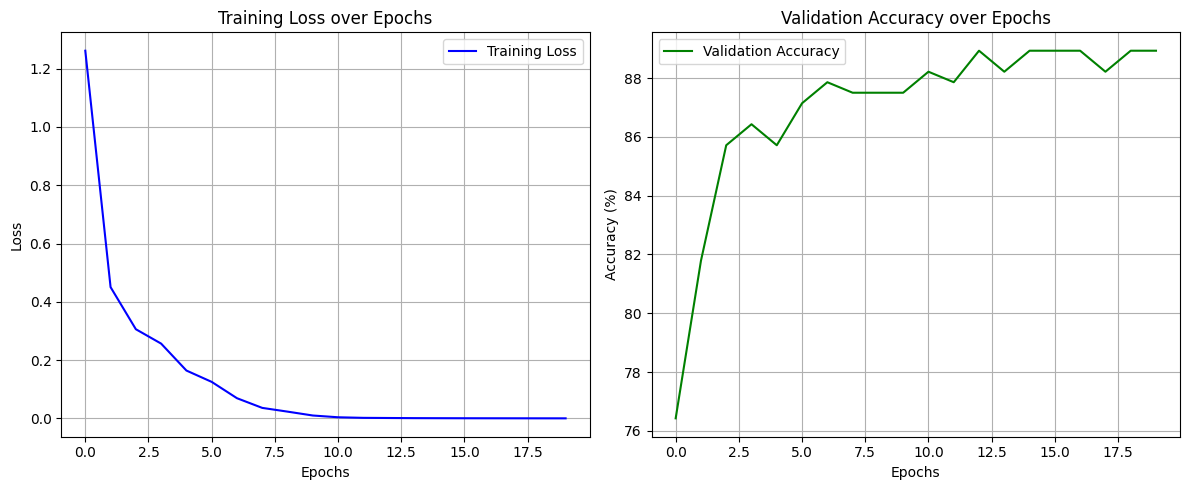

<Figure size 800x800 with 0 Axes>

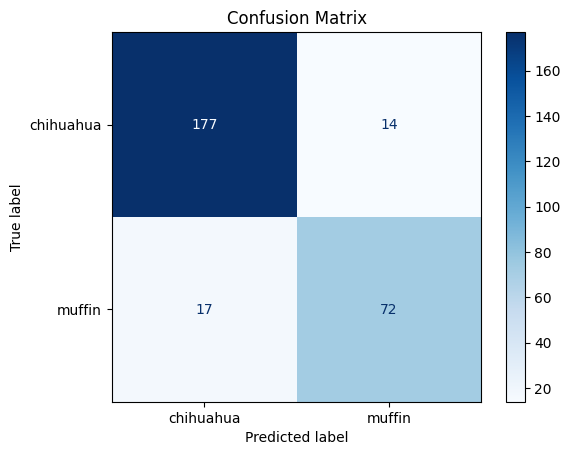

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

# Plot training loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss', color='blue')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Plot validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history['val_accuracy'], label='Validation Accuracy', color='green')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient computation for evaluation
    for input, target in val_loader:
        input, target = get_device_data(input, target)  # Move data to the appropriate device
        output = model(input)  # Forward pass
        _, predicted = torch.max(output.data, 1)  # Get the index of the max log-probability
        y_true.extend(target.cpu().numpy())  # Store true labels
        y_pred.extend(predicted.cpu().numpy())  # Store predicted labels

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=image_dataset.classes)

plt.figure(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()